In [16]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [17]:
df = pd.read_csv('C:\\Users\\sk\\Documents\\backend\\machineai\\Projects\\house_price_Nepal\\data\\raw\\nepal_house_data.csv')

In [18]:
df.head()

,location,area,bedrooms,bathrooms,parking,price
0,Kathmandu,1200,3,2,1,15000000
1,Pokhara,1000,2,1,1,9000000
2,Lalitpur,1500,4,3,2,25000000
3,Bhaktapur,800,2,1,0,7000000
4,Kathmandu,2000,5,4,2,35000000


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   location   10 non-null     str  
 1   area       10 non-null     int64
 2   bedrooms   10 non-null     int64
 3   bathrooms  10 non-null     int64
 4   parking    10 non-null     int64
 5   price      10 non-null     int64
dtypes: int64(5), str(1)
memory usage: 612.0 bytes


In [20]:
df.isnull().sum()

location     0
area         0
bedrooms     0
bathrooms    0
parking      0
price        0
dtype: int64

In [21]:
df.describe()

,area,bedrooms,bathrooms,parking,price
count,10.000000,10.000000,10.000000,10.000000,1.000000e+01
mean,1370.000000,3.300000,2.300000,1.400000,1.935000e+07
std,471.522357,1.159502,1.159502,0.843274,1.181818e+07
min,800.000000,2.000000,1.000000,0.000000,7.000000e+06
25%,1025.000000,2.250000,1.250000,1.000000,9.750000e+06
50%,1250.000000,3.000000,2.000000,1.000000,1.450000e+07
75%,1650.000000,4.000000,3.000000,2.000000,2.725000e+07
max,2200.000000,5.000000,4.000000,3.000000,4.000000e+07


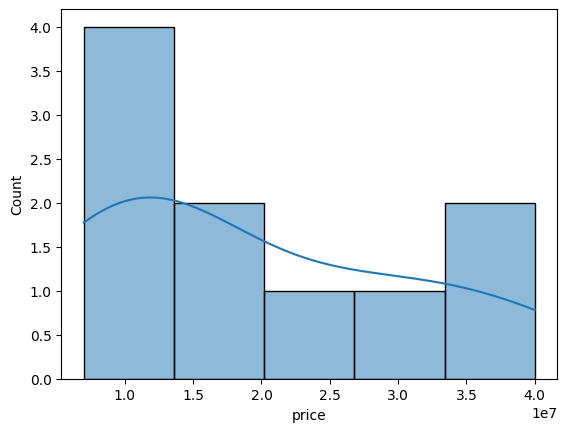

In [22]:
sns.histplot(df['price'], kde=True)
plt.show()

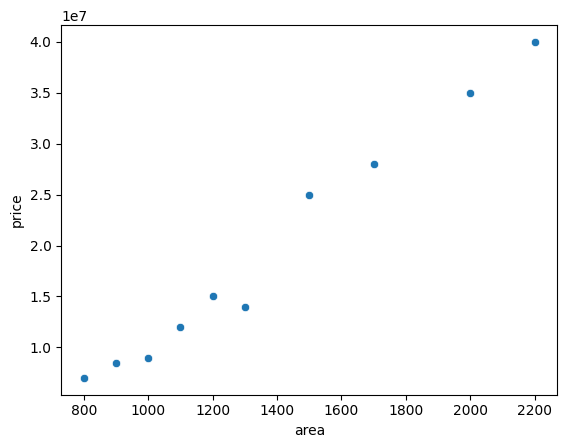

In [23]:
sns.scatterplot(x=df['area'], y=df['price'])
plt.show()

In [28]:
X = df.drop("price", axis=1)
y= df['price']

In [30]:
X = pd.get_dummies(X,columns=['location'],dtype=int)

In [26]:
X.head()

,area,bedrooms,bathrooms,parking,location_Bhaktapur,location_Kathmandu,location_Lalitpur,location_Pokhara
0,1200,3,2,1,0,1,0,0
1,1000,2,1,1,0,0,0,1
2,1500,4,3,2,0,0,1,0
3,800,2,1,0,1,0,0,0
4,2000,5,4,2,0,1,0,0


In [31]:
print(X.columns)

Index(['area', 'bedrooms', 'bathrooms', 'parking', 'location_Bhaktapur',
       'location_Kathmandu', 'location_Lalitpur', 'location_Pokhara'],
      dtype='str')


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
predictions = model.predict(X_test)

In [35]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print(score)

0.9657583246618339


In [ ]:
import pickle


In [37]:
pickle.dump(model, open("../src/model.pkl", "wb"))

In [38]:
loaded_model = pickle.load(open("../src/model.pkl", "rb"))

In [39]:
loaded_model.predict(X_test)

array([37750000.00000525,  5624999.99999816])